In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')

# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------

# Example: Partial molar volumes from density data (water + methanol)

**Generates Table 8.6-2 and Figure 8.6-1.**

Section 8.6 asks a question that sounds like it needs new physics and turns out to need
only a derivative: given how the *volume* of a mixture varies with composition, what is
the partial molar volume $\bar{V}_i$ of each species in it?

The route is Eqs. 8.6-4a and 8.6-4b. If we know the volume change on mixing

$$\Delta_{\text{mix}}\underline{V} = \underline{V}(T,P,\underline{x}) - \sum_i x_i \underline{V}_i(T,P)$$

as a function of $x_1$, then

$$\bar{V}_1 - \underline{V}_1 = \Delta_{\text{mix}}\underline{V} + x_2 \left(\frac{\partial \Delta_{\text{mix}}\underline{V}}{\partial x_1}\right)_{T,P}, \qquad
\bar{V}_2 - \underline{V}_2 = \Delta_{\text{mix}}\underline{V} - x_1 \left(\frac{\partial \Delta_{\text{mix}}\underline{V}}{\partial x_1}\right)_{T,P}$$

Everything hangs on that slope. The book gets it two ways - by drawing a tangent line on
Fig. 8.6-1 and reading its intercepts, and by fitting a curve and differentiating it
analytically. We do both here, and they agree, which is the point: the tangent
construction is not a cruder method, it is the *same* method done by hand.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

> **A production notebook.** The table this notebook writes is a table the book prints,
> so there is one authoritative version of this calculation rather than a self-contained
> notebook and a `_thermo` twin that differ in the last digit. The method still shows:
> `thermo.RedlichKister` is about fifty lines, all of it Eqs. 8.6-5 and 8.6-6.

In [2]:
import sys
sys.path.append("..")           # so `import thermo` finds code/thermo

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Typography, matching the recomputed figures elsewhere in the book: use a real
# LaTeX installation when there is one, so the figure is set in Computer Modern
# like the book, and fall back to matplotlib's own mathtext otherwise - the
# notebook still runs in Colab, which has no TeX.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

from thermo import RedlichKister, tangent_intercepts, load_mixing_data

## The measurements

Table 8.6-1 is a density measurement, not a volume measurement. Each row is the mass
density $\rho$ of a water(1) + methanol(2) mixture of known composition at 298.15 K, and
the molar volume follows from the mixture's molar mass:

$$\underline{V} = \frac{M_{\text{mix}}}{\rho}, \qquad M_{\text{mix}} = x_1 M_1 + x_2 M_2$$

That relation is worth computing rather than trusting, because it is an *identity the
table has to satisfy* - it is how columns 2 and 3 are related. If a digit were wrong
anywhere in the table, this check would find it.

In [3]:
M1, M2 = 18.0153e-3, 32.042e-3        # water, methanol   kg/mol

d = load_mixing_data("water-methanol-volume")
x1 = d["x1"].to_numpy()
x2 = 1.0 - x1

M_mix = x1 * M1 + x2 * M2
V_check = M_mix / d["rho_kg_m3"].to_numpy()

print("identity  V = M_mix / rho")
print(f"  max|deviation| = {np.abs(V_check - d['V_m3_mol']).max():.2e} m^3/mol"
      f"   (table is printed to 1e-10)")

identity  V = M_mix / rho
  max|deviation| = 9.47e-11 m^3/mol   (table is printed to 1e-10)


The pure-component molar volumes are the two end rows, and the volume change on
mixing follows by subtraction. That is the second identity in the table - column 4 is
not an independent measurement, it is columns 1 and 3 combined.

In [4]:
V = d["V_m3_mol"].to_numpy()
V1_pure, V2_pure = V[-1], V[0]                # x1 = 1 is pure water; x1 = 0 pure methanol

dmixV = V - x1 * V1_pure - x2 * V2_pure

print(f"pure water    V1 = {V1_pure*1e6:8.4f} x 1e-6 m^3/mol")
print(f"pure methanol V2 = {V2_pure*1e6:8.4f} x 1e-6 m^3/mol")
print()
print("identity  dmixV = V - x1 V1 - x2 V2")
print(f"  max|deviation| = {np.abs(dmixV - d['dmixV_m3_mol']).max():.2e} m^3/mol")

pure water    V1 =  18.0686 x 1e-6 m^3/mol
pure methanol V2 =  40.7221 x 1e-6 m^3/mol

identity  dmixV = V - x1 V1 - x2 V2
  max|deviation| = 6.69e-11 m^3/mol


Both identities close to the last digit the table prints. The data are clean, and
the mixing is *contractive*: a mole of water and a mole of methanol occupy measurably less
volume together than apart, with the largest effect near $x_1 \approx 0.5$.

## Fitting $\Delta_{\text{mix}}\underline{V}$

$\Delta_{\text{mix}}\underline{V}$ must vanish at both ends, since a pure fluid cannot
change volume on mixing with itself. So it is fitted with a polynomial that vanishes there
by construction - the **Redlich-Kister expansion**, Eq. 8.6-5a:

$$\Delta_{\text{mix}}\underline{V} = x_1 x_2 \sum_{i=0}^{n} a_i (x_1-x_2)^i$$

The book quotes a four-term set for these data. We use it, and we also fit our own from
the table to show that the fit is reproducible rather than magic.

In [5]:
# The constants printed in Sec. 8.6, in m^3/mol
a_book = np.array([-4.0034e-6, -0.17756e-6, 0.54139e-6, 0.60481e-6])
rk = RedlichKister(a_book)

# ... and the same fit made here, from the data in the table
rk_fit = RedlichKister.fit(x1, dmixV, order=3)

print("           a0          a1          a2          a3      (x 1e-6 m^3/mol)")
print("book    " + "  ".join(f"{v*1e6:10.5f}" for v in rk.a))
print("fitted  " + "  ".join(f"{v*1e6:10.5f}" for v in rk_fit.a))
print()
print(f"rms residual, book constants : {rk.rms(x1, dmixV)*1e6:.4f} x 1e-6 m^3/mol")
print(f"rms residual, fitted here    : {rk_fit.rms(x1, dmixV)*1e6:.4f} x 1e-6 m^3/mol")

           a0          a1          a2          a3      (x 1e-6 m^3/mol)
book      -4.00340    -0.17756     0.54139     0.60481
fitted    -4.00683    -0.22175     0.64176     0.84113

rms residual, book constants : 0.0063 x 1e-6 m^3/mol
rms residual, fitted here    : 0.0039 x 1e-6 m^3/mol


The two sets are close but not identical, and ours fits these twelve points noticeably
better - 0.0039 against 0.0063 - which is what a least-squares fit to exactly this data
should do. The book's constants were presumably fitted to more of the original data than
the dozen rows reprinted in Table 8.6-1. We keep them below, so the table this notebook
writes is the table the text describes.

**How many terms?** Four is not obvious, and the answer is not "as many as possible."
`scan_order` fits several orders and reports what each one buys: `rms` on the data,
a leave-one-out cross-validated error (which, unlike `rms`, can get *worse* when a term
stops paying for itself), and the two infinite-dilution partial molar volumes - the
endpoints, where an extrapolated derivative is least trustworthy.

In [6]:
scan = RedlichKister.scan_order(x1, dmixV, orders=range(2, 7))

print("order   rms      LOO-rms   (V1bar-V1)_inf   (V2bar-V2)_inf     [x 1e-6 m^3/mol]")
for s in scan:
    print(f"  {s['order']}   {s['rms']*1e6:7.4f}  {s['loo_rms']*1e6:7.4f}   "
          f"{s['inf_dilution_1']*1e6:12.4f}   {s['inf_dilution_2']*1e6:12.4f}")

order   rms      LOO-rms   (V1bar-V1)_inf   (V2bar-V2)_inf     [x 1e-6 m^3/mol]
  2    0.0114   0.0169        -3.3788        -3.2895
  3    0.0039   0.0079        -3.9844        -2.7457
  4    0.0032   0.0083        -3.7554        -2.5658
  5    0.0026   0.0077        -3.4599        -2.7502
  6    0.0026   0.0259        -3.4300        -2.7387


Read the last two columns, not the first two.

`rms` falls monotonically, as it must - it always does. The cross-validated error does
not: it bottoms out at order 3, sits flat through orders 4 and 5, and then blows up by a
factor of three at order 6, which is the sixth term announcing that it is fitting noise.
That is the honest stopping rule, and it lands on the four constants the book uses.

But now look at the infinite-dilution columns. Between orders 3 and 6 the fitted curve
barely moves, and $(\bar{V}_1-\underline{V}_1)^{\infty}$ moves from $-3.98$ to $-3.43$ -
**about 14%, for a change in the fit you could not see on the plot.** They are the one
place the correlation extrapolates rather than interpolates, and they inherit all of the
uncertainty the interior of the curve absorbs.

This is the thing to carry out of this notebook. A property change on mixing is easy to
correlate and its *derivative at the endpoints* is not, so the two infinite-dilution
entries in Table 8.6-2 deserve less confidence than any other number in it - regardless
of how many decimal places we print.

## Figure 8.6-1

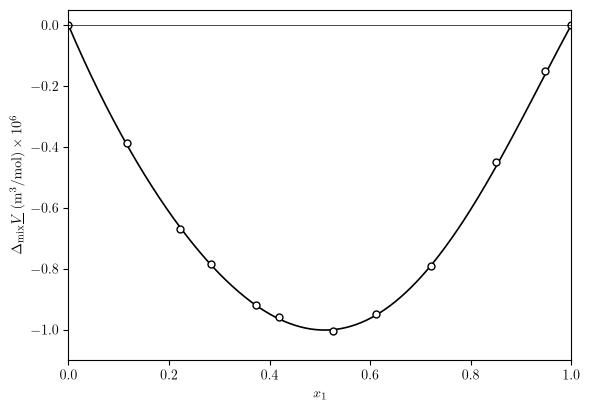

In [7]:
fig, ax = plt.subplots(figsize=(6.0, 4.2))

xs = np.linspace(0.0, 1.0, 400)
ax.plot(xs, rk(xs) * 1e6, "-", color="black", lw=1.2)
ax.plot(x1, dmixV * 1e6, "o", mfc="white", mec="black", ms=5, lw=0)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$\Delta_{\mathrm{mix}}\underline{V}\;(\mathrm{m^3/mol}) \times 10^{6}$")
ax.set_xlim(0, 1)
ax.set_ylim(-1.1, 0.05)
ax.axhline(0.0, color="black", lw=0.5)

fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_8.6-1.pdf")
plt.show()

## The tangent construction, as arithmetic

Before computing the whole table, do one composition by the graphical route of Sec. 8.6,
because it is the step students are asked to do by hand. Draw the tangent to the curve at
$x_1^{*}$; where it crosses the ordinate at $x_1 = 0$ is $(\bar{V}_2 - \underline{V}_2)$
(point $A$ in Fig. 8.6-1), and where it crosses at $x_1 = 1$ is
$(\bar{V}_1 - \underline{V}_1)$ (point $B$).

This needs only a point and a slope. So it is a genuinely independent check on
Eqs. 8.6-6a,b - if the two disagreed, the algebra would be wrong.

In [8]:
x_star = 0.5266                                   # a row of Table 8.6-1

A, B = tangent_intercepts(x_star, rk(x_star), rk.derivative(x_star))
d1, d2 = rk.partial_molar_excess(x_star)

print(f"at x1 = {x_star}")
print(f"  tangent intercept at x1=1 (point B) : {B*1e6:9.4f}   Eq. 8.6-6b: {d1*1e6:9.4f}")
print(f"  tangent intercept at x1=0 (point A) : {A*1e6:9.4f}   Eq. 8.6-6a: {d2*1e6:9.4f}")
print("                                                       [x 1e-6 m^3/mol]")

at x1 = 0.5266
  tangent intercept at x1=1 (point B) :   -0.9260   Eq. 8.6-6b:   -0.9260
  tangent intercept at x1=0 (point A) :   -1.0822   Eq. 8.6-6a:   -1.0822
                                                       [x 1e-6 m^3/mol]


## Table 8.6-2

Now the same calculation at every composition. Two things are worth watching as you read
down the table.

**Each species approaches its pure-component value as its own mole fraction approaches 1,
and departs most from it at infinite dilution.** That is not an artifact of the fit; it is
the physical statement that a molecule surrounded by its own kind behaves as it does in
the pure fluid, while a molecule surrounded entirely by strangers does not.

**The summation identity holds exactly.**
$x_1(\bar{V}_1-\underline{V}_1) + x_2(\bar{V}_2-\underline{V}_2) = \Delta_{\text{mix}}\underline{V}$
is Eq. 8.1-14, and Eqs. 8.6-6a,b satisfy it *by construction* - so agreement there
confirms the algebra, not the fit. The residuals above are what say whether the fit is
any good.

In [9]:
d1, d2 = rk.partial_molar_excess(x1)

table = pd.DataFrame({
    "x1": x1,
    "V1bar - V1": d1 * 1e6,
    "V1bar": (V1_pure + d1) * 1e6,
    "V2bar - V2": d2 * 1e6,
    "V2bar": (V2_pure + d2) * 1e6,
})

identity = np.abs(x1 * d1 + x2 * d2 - rk(x1)).max()
print(f"summation identity (Eq. 8.1-14)  max|deviation| = {identity:.2e} m^3/mol\n")
print(table.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
print("\nall entries x 1e-6 m^3/mol")

summation identity (Eq. 8.1-14)  max|deviation| = 2.12e-22 m^3/mol

       x1  V1bar - V1     V1bar  V2bar - V2     V2bar
   0.0000     -3.8893   14.1793     -0.0000   40.7221
   0.1162     -2.9741   15.0945     -0.0530   40.6691
   0.2221     -2.3833   15.6853     -0.1727   40.5494
   0.2841     -2.0751   15.9935     -0.2773   40.4448
   0.3729     -1.6452   16.4234     -0.4884   40.2337
   0.4186     -1.4260   16.6426     -0.6321   40.0900
   0.5266     -0.9260   17.1426     -1.0822   39.6399
   0.6119     -0.5752   17.4934     -1.5464   39.1757
   0.7220     -0.2294   17.8392     -2.2363   38.4858
   0.8509     -0.0254   18.0432     -2.9631   37.7590
   0.9489      0.0026   18.0712     -3.1689   37.5532
   1.0000      0.0000   18.0686     -3.0348   37.6873

all entries x 1e-6 m^3/mol


The two infinite-dilution values are the first and last rows: a mole of water dropped
into pure methanol contributes about 3.9 units less volume than it would as pure water, and
a mole of methanol dropped into pure water about 3.0 units less than as pure methanol.
These are the numbers the order scan above showed to be least certain - they are
extrapolations, and they should be quoted as such.

In [10]:
os.makedirs("output", exist_ok=True)
table.to_csv("output/Table_8.6-2.csv", index=False)

with open("output/Table_8.6-2.txt", "w") as fh:
    fh.write("Table 8.6-2  The Partial Molar Volumes of the Water(1)-Methanol(2) "
             "System at T = 298.15 K\n")
    fh.write("All entries (m^3/mol) x 1e6.  Computed from Table 8.6-1 by a "
             "Redlich-Kister correlation\n")
    fh.write(f"of the volume change on mixing, order {rk.order} "
             f"(Eqs. 8.6-5a, 8.6-6a, 8.6-6b).\n\n")
    fh.write(table.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
    fh.write("\n\nThe x1 = 0 and x1 = 1 rows are the infinite-dilution values.\n")

print("wrote output/Table_8.6-2.csv and output/Table_8.6-2.txt")

wrote output/Table_8.6-2.csv and output/Table_8.6-2.txt


## Your turn

1. **Push the order and watch the ends.** Rebuild the table with `order=2` and with
   `order=6`. The curve through the data barely moves. How much do the two
   infinite-dilution volumes move? Which number in Table 8.6-2 would you be least willing
   to defend to three decimal places?

2. **Do it without the fit.** Estimate the slope at each tabulated composition by a finite
   difference on the neighboring points, then use `tangent_intercepts` directly. Where does
   this agree with the correlation, and where does it fail? (Look hard at the two end
   rows, and ask what a finite difference can possibly say there.)

3. **A different property, same machinery.** `RedlichKister` never mentions volume. Load
   `water-methanol-enthalpy` and run this notebook's calculation on
   $\Delta_{\text{mix}}\underline{H}$ instead - that is Table 8.6-4, and it is the subject
   of the companion notebook.

4. **Predict the sign.** For water + methanol the volume change on mixing is negative
   everywhere, and so are both partial molar excesses. Sketch what
   $\Delta_{\text{mix}}\underline{V}$ would look like for a mixture that expands on mixing,
   and convince yourself from Eqs. 8.6-6a,b that both excesses would then be positive.
   Must they always have the same sign as each other? (Try
   $a_0 = 0$, $a_1 = 1$ and see.)